In [1]:
# ── Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Abhigna\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Abhigna\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Abhigna\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
# ── Load Data ────────────────────────────────────────────────────────

# Column names as per LIAR dataset documentation
columns = [
    "id", "label", "statement", "subject", "speaker",
    "job", "state", "party", "barely_true_ct", "false_ct",
    "half_true_ct", "mostly_true_ct", "pants_fire_ct", "context"
]

# Load all three splits
train_df = pd.read_csv("../data/raw/train.tsv", sep="\t", header=None, names=columns)
val_df   = pd.read_csv("../data/raw/valid.tsv", sep="\t", header=None, names=columns)
test_df  = pd.read_csv("../data/raw/test.tsv",  sep="\t", header=None, names=columns)

print(f"Train size : {train_df.shape}")
print(f"Val size   : {val_df.shape}")
print(f"Test size  : {test_df.shape}")

train_df.head()

Train size : (10240, 14)
Val size   : (1284, 14)
Test size  : (1267, 14)


,id,label,statement,subject,speaker,job,state,party,barely_true_ct,false_ct,half_true_ct,mostly_true_ct,pants_fire_ct,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [3]:
# ── Basic Data Exploration ───────────────────────────────────────────

print("="*50)
print("BASIC DATASET INFO")
print("="*50)

print("\n--- Data Types ---")
print(train_df.dtypes)

print("\n--- Missing Values in Train ---")
print(train_df.isnull().sum())

print("\n--- Label Distribution ---")
print(train_df['label'].value_counts())

BASIC DATASET INFO

--- Data Types ---
id                 object
label              object
statement          object
subject            object
speaker            object
job                object
state              object
party              object
barely_true_ct    float64
false_ct          float64
half_true_ct      float64
mostly_true_ct    float64
pants_fire_ct     float64
context            object
dtype: object

--- Missing Values in Train ---
id                   0
label                0
statement            0
subject              2
speaker              2
job               2898
state             2210
party                2
barely_true_ct       2
false_ct             2
half_true_ct         2
mostly_true_ct       2
pants_fire_ct        2
context            102
dtype: int64

--- Label Distribution ---
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64


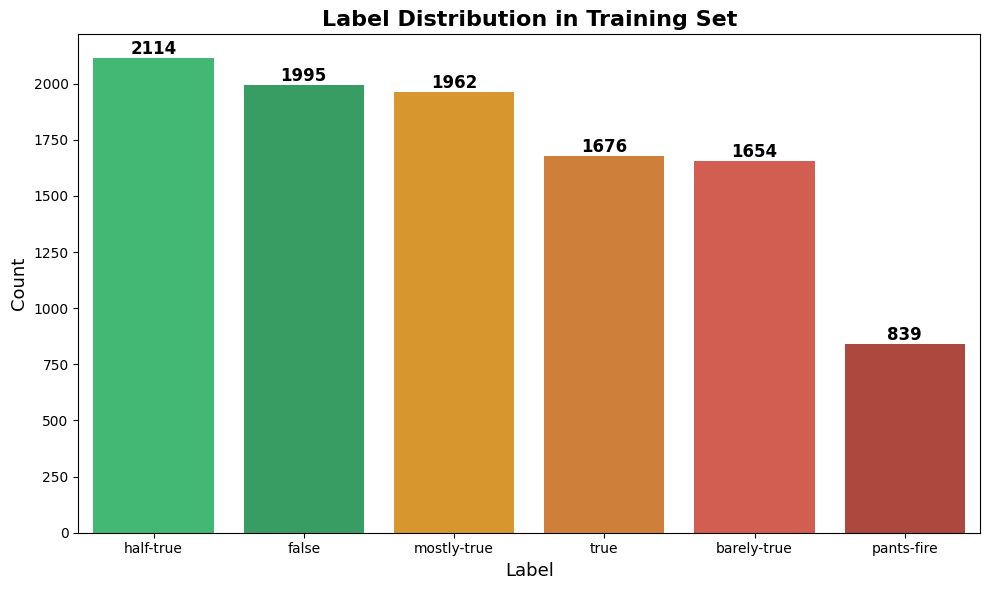

Plot saved!


In [4]:
# ── Visualization 1: Label Distribution ─────────────────────────────

plt.figure(figsize=(10, 6))

# Define colors for each label
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']

ax = sns.countplot(data=train_df, x='label', order=train_df['label'].value_counts().index, palette=colors)

# Add count numbers on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Label Distribution in Training Set', fontsize=16, fontweight='bold')
plt.xlabel('Label', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/label_distribution.png', dpi=150)
plt.show()

print("Plot saved!")

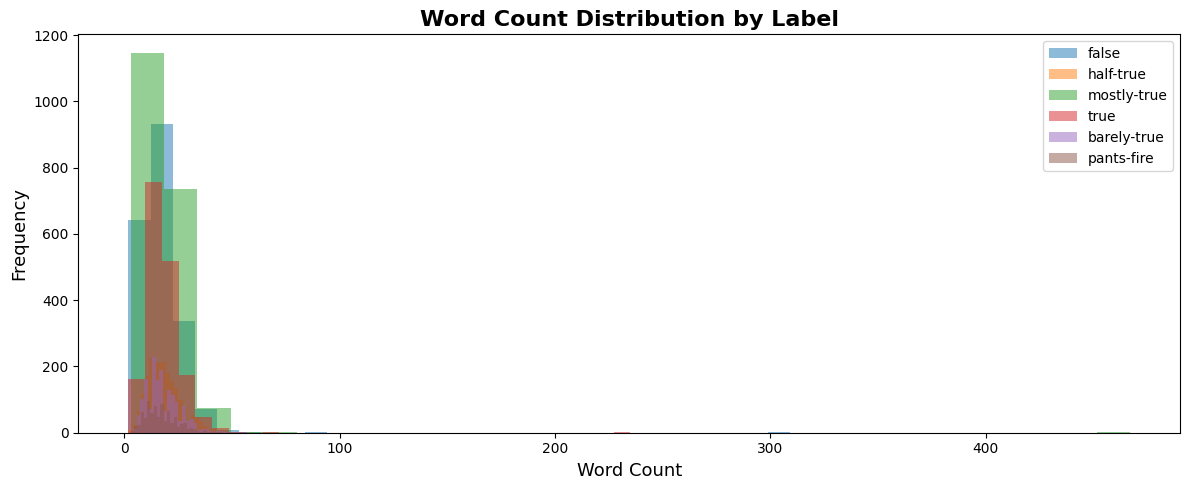

Average word count : 18.0
Max word count     : 467
Min word count     : 2


In [5]:
# ── Visualization 2: Word Count Histogram ───────────────────────────

# Count words in each statement
train_df['word_count'] = train_df['statement'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))

# Plot histogram for each label
for label in train_df['label'].unique():
    subset = train_df[train_df['label'] == label]['word_count']
    plt.hist(subset, bins=30, alpha=0.5, label=label)

plt.title('Word Count Distribution by Label', fontsize=16, fontweight='bold')
plt.xlabel('Word Count', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/word_count_histogram.png', dpi=150)
plt.show()

print(f"Average word count : {train_df['word_count'].mean():.1f}")
print(f"Max word count     : {train_df['word_count'].max()}")
print(f"Min word count     : {train_df['word_count'].min()}")

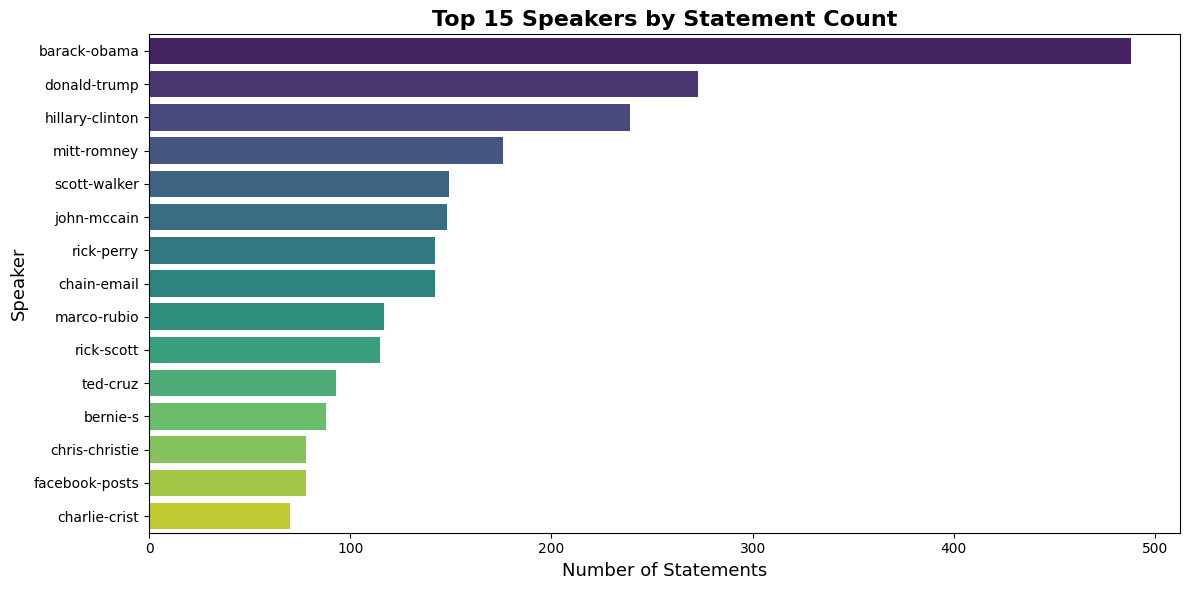

speaker
barack-obama       488
donald-trump       273
hillary-clinton    239
mitt-romney        176
scott-walker       149
john-mccain        148
rick-perry         142
chain-email        142
marco-rubio        117
rick-scott         115
ted-cruz            93
bernie-s            88
chris-christie      78
facebook-posts      78
charlie-crist       70
Name: count, dtype: int64


In [6]:
# ── Visualization 3: Top Speakers ───────────────────────────────────

plt.figure(figsize=(12, 6))

top_speakers = train_df['speaker'].value_counts().head(15)

sns.barplot(x=top_speakers.values, y=top_speakers.index, palette='viridis')

plt.title('Top 15 Speakers by Statement Count', fontsize=16, fontweight='bold')
plt.xlabel('Number of Statements', fontsize=13)
plt.ylabel('Speaker', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/top_speakers.png', dpi=150)
plt.show()

print(top_speakers)

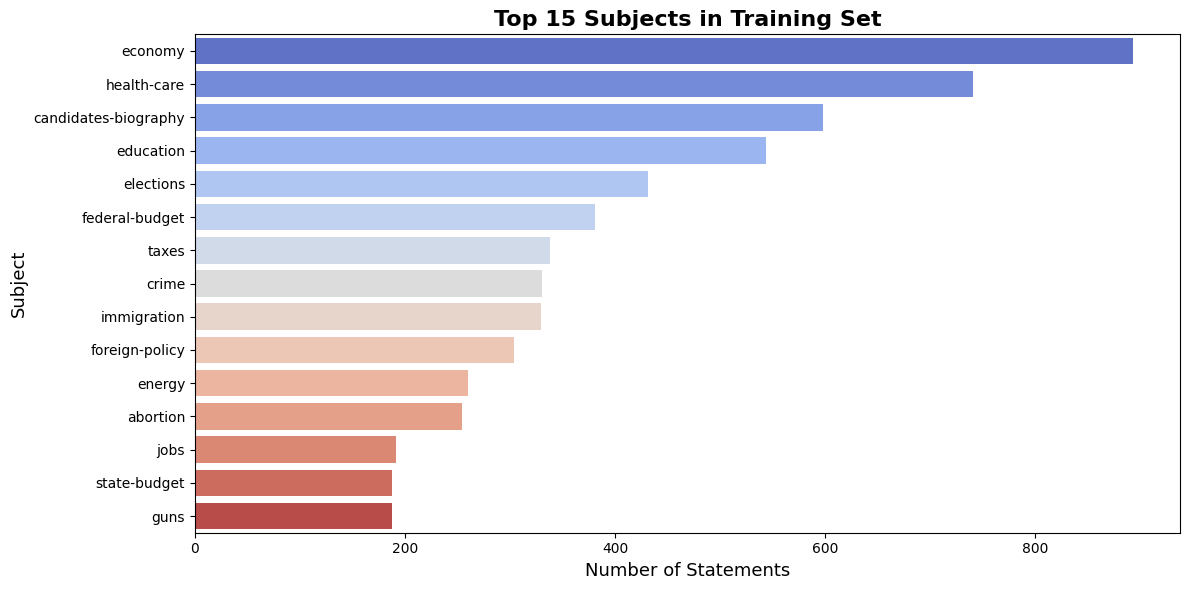

primary_subject
economy                 893
health-care             741
candidates-biography    598
education               544
elections               431
federal-budget          381
taxes                   338
crime                   330
immigration             329
foreign-policy          304
energy                  260
abortion                254
jobs                    191
state-budget            188
guns                    188
Name: count, dtype: int64


In [7]:
# ── Visualization 4: Subject Analysis ───────────────────────────────

plt.figure(figsize=(12, 6))

# Some statements have multiple subjects separated by comma — take the first one
train_df['primary_subject'] = train_df['subject'].apply(lambda x: str(x).split(',')[0])

top_subjects = train_df['primary_subject'].value_counts().head(15)

sns.barplot(x=top_subjects.values, y=top_subjects.index, palette='coolwarm')

plt.title('Top 15 Subjects in Training Set', fontsize=16, fontweight='bold')
plt.xlabel('Number of Statements', fontsize=13)
plt.ylabel('Subject', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/subject_analysis.png', dpi=150)
plt.show()

print(top_subjects)

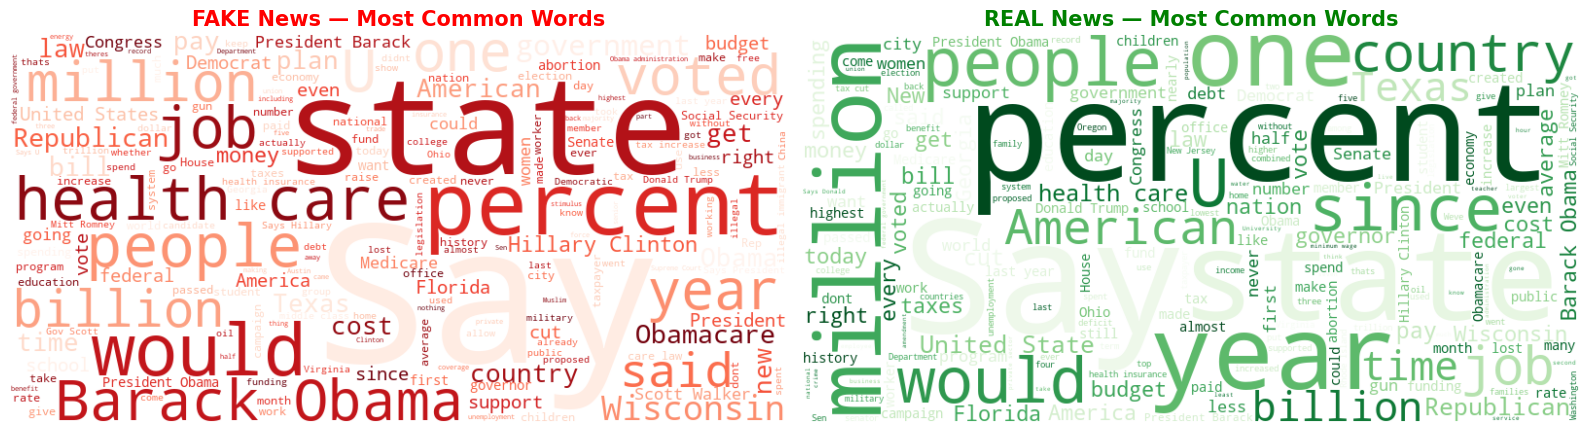

Word clouds saved!


In [8]:
# ── Visualization 5: Word Clouds (Fake vs Real) ──────────────────────

from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Group labels into binary: fake vs real
fake_labels = ['false', 'barely-true', 'pants-fire']
real_labels = ['true', 'mostly-true', 'half-true']

fake_text = ' '.join(train_df[train_df['label'].isin(fake_labels)]['statement'].astype(str).tolist())
real_text = ' '.join(train_df[train_df['label'].isin(real_labels)]['statement'].astype(str).tolist())

# Generate word clouds
fake_wc = WordCloud(width=800, height=400, background_color='white',
                    stopwords=stop_words, colormap='Reds').generate(fake_text)

real_wc = WordCloud(width=800, height=400, background_color='white',
                    stopwords=stop_words, colormap='Greens').generate(real_text)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(fake_wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('FAKE News — Most Common Words', fontsize=15, fontweight='bold', color='red')

axes[1].imshow(real_wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('REAL News — Most Common Words', fontsize=15, fontweight='bold', color='green')

plt.tight_layout()
plt.savefig('../outputs/figures/wordclouds.png', dpi=150)
plt.show()

print("Word clouds saved!")

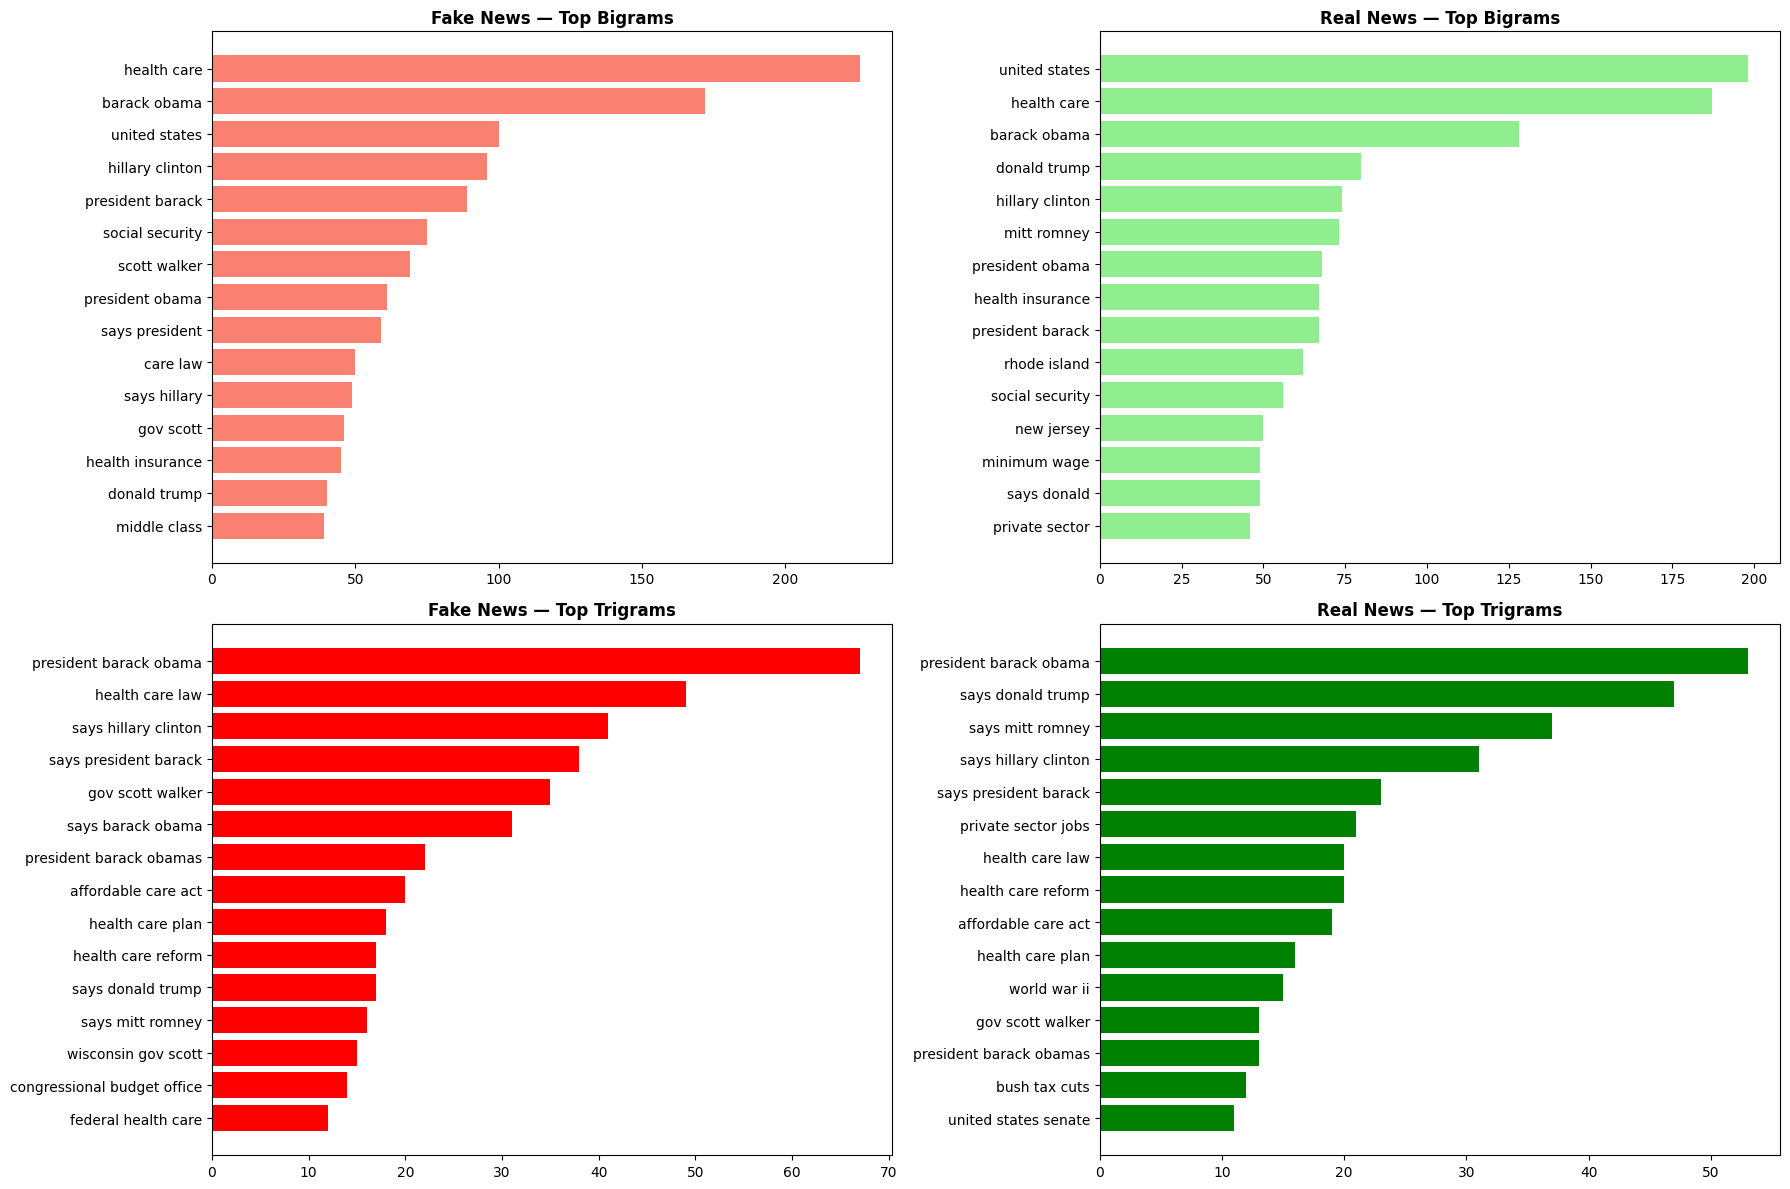

Bigrams & Trigrams saved!


In [9]:
# ── Visualization 6: Top Bigrams & Trigrams ─────────────────────────

from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n, top_k=15):
    vectorizer = CountVectorizer(ngram_range=(n, n), stop_words='english')
    X = vectorizer.fit_transform(corpus)
    freqs = zip(vectorizer.get_feature_names_out(), X.sum(axis=0).tolist()[0])
    return sorted(freqs, key=lambda x: x[1], reverse=True)[:top_k]

fake_corpus = train_df[train_df['label'].isin(['false','barely-true','pants-fire'])]['statement'].astype(str)
real_corpus = train_df[train_df['label'].isin(['true','mostly-true','half-true'])]['statement'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Fake Bigrams
fake_bigrams = get_top_ngrams(fake_corpus, 2)
axes[0,0].barh([x[0] for x in fake_bigrams], [x[1] for x in fake_bigrams], color='salmon')
axes[0,0].set_title('Fake News — Top Bigrams', fontweight='bold')
axes[0,0].invert_yaxis()

# Real Bigrams
real_bigrams = get_top_ngrams(real_corpus, 2)
axes[0,1].barh([x[0] for x in real_bigrams], [x[1] for x in real_bigrams], color='lightgreen')
axes[0,1].set_title('Real News — Top Bigrams', fontweight='bold')
axes[0,1].invert_yaxis()

# Fake Trigrams
fake_trigrams = get_top_ngrams(fake_corpus, 3)
axes[1,0].barh([x[0] for x in fake_trigrams], [x[1] for x in fake_trigrams], color='red')
axes[1,0].set_title('Fake News — Top Trigrams', fontweight='bold')
axes[1,0].invert_yaxis()

# Real Trigrams
real_trigrams = get_top_ngrams(real_corpus, 3)
axes[1,1].barh([x[0] for x in real_trigrams], [x[1] for x in real_trigrams], color='green')
axes[1,1].set_title('Real News — Top Trigrams', fontweight='bold')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/figures/ngrams.png', dpi=150)
plt.show()

print("Bigrams & Trigrams saved!")

In [10]:
# ── Text Cleaning Pipeline ───────────────────────────────────────────

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Step 1: Lowercase
    text = str(text).lower()
    
    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Step 3: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Step 4: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 5: Remove stopwords + Lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return ' '.join(tokens)

# Apply to all three splits
train_df['cleaned_statement'] = train_df['statement'].apply(clean_text)
val_df['cleaned_statement']   = val_df['statement'].apply(clean_text)
test_df['cleaned_statement']  = test_df['statement'].apply(clean_text)

# Preview the result
print("Original statement:")
print(train_df['statement'][0])
print("\nCleaned statement:")
print(train_df['cleaned_statement'][0])


Original statement:
Says the Annies List political group supports third-trimester abortions on demand.

Cleaned statement:
say annies list political group support thirdtrimester abortion demand


In [11]:
# ── Text Cleaning Pipeline (Fixed) ───────────────────────────────────

def clean_text(text):
    # Step 1: Lowercase
    text = str(text).lower()
    
    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Step 3: Replace hyphens with space
    text = text.replace('-', ' ')
    
    # Step 4: Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Step 5: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 6: Remove stopwords + Lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return ' '.join(tokens)

# Re-apply to all three splits
train_df['cleaned_statement'] = train_df['statement'].apply(clean_text)
val_df['cleaned_statement']   = val_df['statement'].apply(clean_text)
test_df['cleaned_statement']  = test_df['statement'].apply(clean_text)

# Preview
print("Original statement:")
print(train_df['statement'][0])
print("\nCleaned statement:")
print(train_df['cleaned_statement'][0])

Original statement:
Says the Annies List political group supports third-trimester abortions on demand.

Cleaned statement:
say annies list political group support third trimester abortion demand


In [12]:
# ── Feature Engineering ──────────────────────────────────────────────

def get_caps_ratio(text):
    text = str(text)
    if len(text) == 0:
        return 0
    caps = sum(1 for c in text if c.isupper())
    return caps / len(text)

def get_exclamation_count(text):
    return str(text).count('!')

def get_question_mark_count(text):
    return str(text).count('?')

# Apply to all three splits
for df in [train_df, val_df, test_df]:
    df['caps_ratio']          = df['statement'].apply(get_caps_ratio)
    df['exclamation_count']   = df['statement'].apply(get_exclamation_count)
    df['question_mark_count'] = df['statement'].apply(get_question_mark_count)

# Preview
print(train_df[['statement', 'caps_ratio', 'exclamation_count', 'question_mark_count']].head())

# Quick stats
print("\n--- Feature Stats ---")
print(f"Avg caps ratio       : {train_df['caps_ratio'].mean():.3f}")
print(f"Max exclamation count: {train_df['exclamation_count'].max()}")
print(f"Max question marks   : {train_df['question_mark_count'].max()}")

                                           statement  caps_ratio  \
0  Says the Annies List political group supports ...    0.036585   
1  When did the decline of coal start? It started...    0.042553   
2  Hillary Clinton agrees with John McCain "by vo...    0.076190   
3  Health care reform legislation is likely to ma...    0.012821   
4  The economic turnaround started at the end of ...    0.018519   

   exclamation_count  question_mark_count  
0                  0                    0  
1                  0                    1  
2                  0                    0  
3                  0                    0  
4                  0                    0  

--- Feature Stats ---
Avg caps ratio       : 0.037
Max exclamation count: 5
Max question marks   : 2


In [13]:
# ── Fill Missing Values ──────────────────────────────────────────────

cols_to_fill = ['subject', 'speaker', 'job', 'state', 'party', 'context']

for df in [train_df, val_df, test_df]:
    for col in cols_to_fill:
        df[col] = df[col].fillna('unknown')

# Verify
print("Missing values after filling:")
print(train_df.isnull().sum())

Missing values after filling:
id                     0
label                  0
statement              0
subject                0
speaker                0
job                    0
state                  0
party                  0
barely_true_ct         2
false_ct               2
half_true_ct           2
mostly_true_ct         2
pants_fire_ct          2
context                0
word_count             0
primary_subject        0
cleaned_statement      0
caps_ratio             0
exclamation_count      0
question_mark_count    0
dtype: int64


In [14]:
# ── Save Processed Splits ────────────────────────────────────────────

import os

save_path = '../data/processed/'

train_df.to_csv(os.path.join(save_path, 'train_processed.csv'), index=False)
val_df.to_csv(os.path.join(save_path,   'val_processed.csv'),   index=False)
test_df.to_csv(os.path.join(save_path,  'test_processed.csv'),  index=False)

print("Files saved successfully!")
print(f"\nTrain shape : {train_df.shape}")
print(f"Val shape   : {val_df.shape}")
print(f"Test shape  : {test_df.shape}")

print("\nColumns in processed data:")
for col in train_df.columns:
    print(f"  → {col}")
    

Files saved successfully!

Train shape : (10240, 20)
Val shape   : (1284, 18)
Test shape  : (1267, 18)

Columns in processed data:
  → id
  → label
  → statement
  → subject
  → speaker
  → job
  → state
  → party
  → barely_true_ct
  → false_ct
  → half_true_ct
  → mostly_true_ct
  → pants_fire_ct
  → context
  → word_count
  → primary_subject
  → cleaned_statement
  → caps_ratio
  → exclamation_count
  → question_mark_count
